# Comment Toxicity Model

### 1. Load your data

In [1]:
#mount drive, load data, install dependencies

from google.colab import drive
drive.mount('/content/drive')

!pip install -q tensorflow scikit-learn

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf


# update these paths to match your Drive folder

train_path = '/content/drive/MyDrive/Data Science Program - HCL GUVI/Comment_Toxicity/train.csv'
test_path = '/content/drive/MyDrive/Data Science Program - HCL GUVI/Comment_Toxicity/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
print("\nFirst few rows:", train_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (159571, 8)
Test shape: (153164, 2)

Train columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

First few rows:                  id  ... identity_hate
0  0000997932d777bf  ...             0
1  000103f0d9cfb60f  ...             0
2  000113f07ec002fd  ...             0
3  0001b41b1c6bb37e  ...             0
4  0001d958c54c6e35  ...             0

[5 rows x 8 columns]


### 2. Explore the data (EDA)

Text columns: comment_text
Label columns: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Positive label counts
 toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


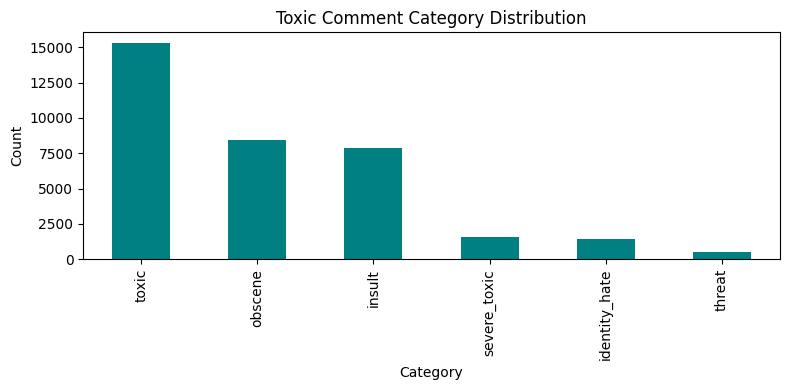

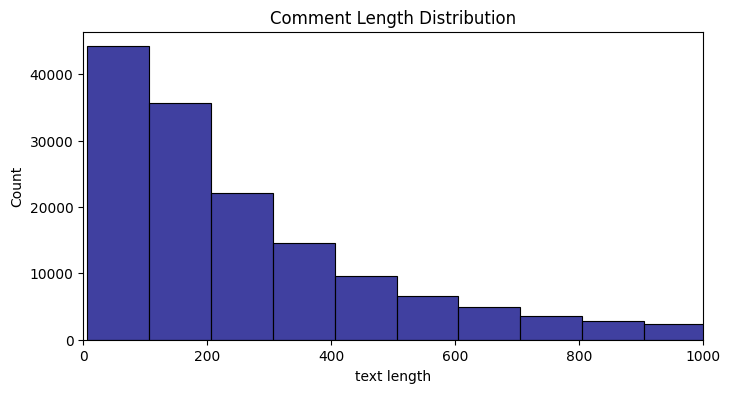


Sample toxic comment:
COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK


In [2]:
# auto-detect label columns (except id/comment_text)
text_col = 'comment_text' if 'comment_text' in train_df.columns else train_df.columns[1]
label_cols = [c for c in train_df.columns if c not in ['id', text_col]]
print("Text columns:", text_col)
print("Label columns:", label_cols)

#check for missing values
print("\nMissing values:\n", train_df.isnull().sum())

#class distribution for each label
if label_cols:
  label_counts = train_df[label_cols].sum().sort_values(ascending=False)
  print("\nPositive label counts\n", label_counts)
  plt.figure(figsize=(8,4))
  label_counts.plot(kind='bar', color='teal')
  plt.title("Toxic Comment Category Distribution")
  plt.ylabel("Count")
  plt.xlabel("Category")
  plt.tight_layout()
  plt.show()

#comment length distribution
train_df['text length'] = train_df[text_col].astype(str).apply(len)
plt.figure(figsize=(8,4))
sns.histplot(train_df['text length'], bins=50, color='navy')
plt.title("Comment Length Distribution")
plt.xlim(0, 1000)
plt.show()

print("\nSample toxic comment:")
if label_cols:
  print(train_df[train_df[label_cols[0]] == 1][text_col].iloc[0])

### 3. Text cleaning

In [3]:
def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'http\S+|www\S+', '', text)    #remove URLs
  text = re.sub(r'\n', '', text)                #remove newlines
  text = re.sub(r'\[.*?\]', '', text)           #remove bracketed text
  text = re.sub(r'[^a-zA-Z\s]', '', text)       #remove non-alphanumeric
  text = re.sub(r'\s+', ' ', text)              #remove extra spaces
  return text.strip()

train_df['clean_text'] = train_df[text_col].apply(clean_text)
test_df['clean_text'] = test_df[text_col].apply(clean_text)

print("Before:", train_df[text_col].iloc[0][:150])
print("After:", train_df['clean_text'].iloc[0][:150])

Before: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted
After: explanationwhy the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at 


### 4. Tokenization & Sequence padding

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

max_vocab = 20000
max_len = 150
tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_text'])

x = tokenizer.texts_to_sequences(train_df['clean_text'])
x = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

y = train_df[label_cols].values

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

print("X_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)

X_train shape:  (127656, 150)
y_train shape:  (127656, 6)


### 5. Build LSTM model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
EMBED_DIM = 128
model = Sequential([
    Embedding(input_dim=max_vocab, output_dim=EMBED_DIM, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(label_cols), activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 6. Train the model

Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.8246 - auc: 0.9449 - loss: 0.0807 - val_accuracy: 0.9941 - val_auc: 0.9765 - val_loss: 0.0513
Epoch 2/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9543 - auc: 0.9805 - loss: 0.0484 - val_accuracy: 0.9941 - val_auc: 0.9794 - val_loss: 0.0491
Epoch 3/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.9478 - auc: 0.9858 - loss: 0.0430 - val_accuracy: 0.9941 - val_auc: 0.9706 - val_loss: 0.0517
Epoch 4/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9322 - auc: 0.9890 - loss: 0.0387 - val_accuracy: 0.9941 - val_auc: 0.9707 - val_loss: 0.0524


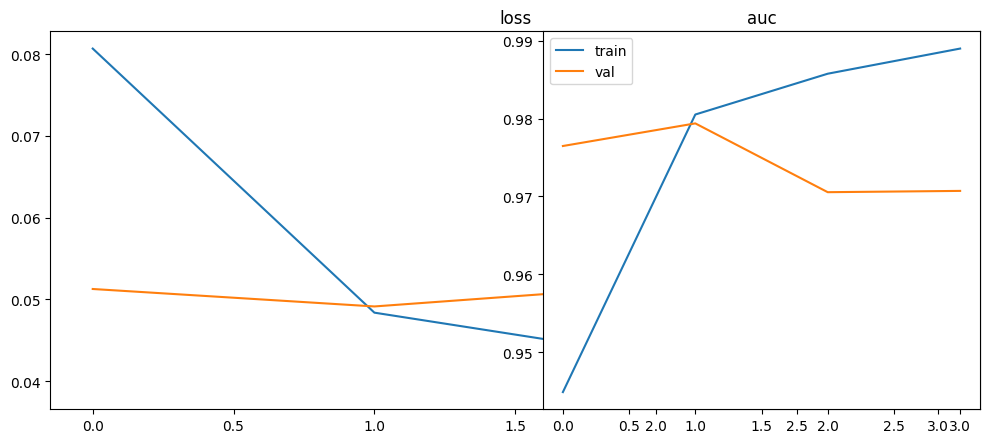

In [14]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_loss', patience = 2, restore_best_weights=True)
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=128, callbacks=[early_stop])
#plot training curves
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label = 'train')
plt.plot(history.history['val_auc'], label = 'val')
plt.title('auc')
plt.legend()
plt.tight_layout()
plt.show()

### 7. Evaluation

In [15]:
from sklearn.metrics import classification_report, roc_auc_score
y_pred_prob = model.predict(x_val)
y_pred = (y_pred_prob > 0.5).astype(int)
for i, col in enumerate(label_cols):
  print(f"\n--- {col} ---")
  print(classification_report(y_val[:, i], y_pred[:, i], zero_division=0))
  try:
    auc = roc_auc_score(y_val[:, i], y_pred_prob[:, 1])
    print(f"AUC: {auc:.4f}")
  except ValueError:
    pass


998/998 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step

--- toxic ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28859
           1       0.85      0.74      0.79      3056

    accuracy                           0.96     31915
   macro avg       0.91      0.86      0.88     31915
weighted avg       0.96      0.96      0.96     31915

AUC: 0.9749

--- severe_toxic ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     31594
           1       0.78      0.04      0.08       321

    accuracy                           0.99     31915
   macro avg       0.88      0.52      0.54     31915
weighted avg       0.99      0.99      0.99     31915

AUC: 0.9880

--- obscene ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     30200
           1       0.86      0.74      0.79      1715

    accuracy                           0.98     31915
   macro 

### 8. Save model & tokenizer

In [17]:
import pickle
import os
os.makedirs('/content/drive/MyDrive/Data Science Program - HCL GUVI/Comment_Toxicity/models', exist_ok=True)
model.save('/content/drive/MyDrive/Data Science Program - HCL GUVI/Comment_Toxicity/models/toxicity_model.h5')
with open('/content/drive/MyDrive/Data Science Program - HCL GUVI/Comment_Toxicity/models/tokenizer.pkl', 'wb') as f:
  pickle.dump(tokenizer, f)

#save label columns and max_len too
config = {'label_cols': label_cols, 'max_len': max_len}
with open('/content/drive/MyDrive/Data Science Program - HCL GUVI/Comment_Toxicity/models/config.pkl', 'wb') as f:
  pickle.dump(config, f)
print("Saved model, tokenizer and config to Drive")

Saved model, tokenizer and config to Drive
